# Image loading and visualization

This notebook demonstrates how to create, inspect, and visualize detector images using the `ImageCreator`
task and the `DetImage` datamodel. It shows typical workflows: loading raw FITS, inspecting outputs,
combining detectors into a focal plane, and creating a master bias. Each section contains a brief
explanation and the minimal example code you need to reproduce the step.

Imports and setup
 - Import only what is needed for the examples below.
 - Ensure your `PYTHONPATH` includes the project root (or install the package) so imports resolve.
 - Replace the example file paths with paths valid on your machine.

## Example 1: Create images from raw files

Use `ImageCreator` task to convert raw FITS input into high-level `DetImage` objects.

Initializing `ImageCreator` requires a path to a detector configuration file that defines the structure of the raw data and how to parse it.
- Pass a `detector_config` to `ImageCreator` (path to a YAML/JSON file or a Python `dict`) to describe detector geometry and per-output metadata.
- The detector config controls:
  - mapping of data in FITS extensions to detector/outputs of a detector,
  - per-output information and metadata depending on the detector type, e.g. prescan/overscan slices,
  - focal-plane placement

The `run` method of `ImageCreator` accepts the raw data input and produces a dictionary of `DetImage` objects.
- `input_source` accepts a single file, list of files, directory, or glob pattern, OR arrays from buffer
- Optionally provide `identifier_func` to control how files are classified (bias, object, flat, ...)
- Optionally provide `fitsloader_func` to control how raw FITS files are read-in and add custom preprocessing logic
- The return value is a dictionary keyed by image type (e.g. `'object'`, `'bias'`) whose values are lists
  of `DetImage` objects.

In [1]:
from eregion.tasks.imagegen import ImageCreator

# Initialize the ImageCreator with the detector configuration.
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci_raw.yaml')
res = creator.run(input_source='../data/deimos/warmdark_allchans.fits')

2026-07-22 15:54:40,309 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci_raw.yaml'
2026-07-22 15:54:40,310 - image_creator - INFO - Item ../data/deimos/warmdark_allchans.fits is a regular path string


The output of `ImageCreator.run()` is `ImageResult` object (subclass of `TaskResult`, a mappable). All `TaskResult` objects have meta attributes (`params`, `upstream`, `timestamp`) and payload attributes (the actual data). Use its `get_schema()` method to inspect the schema of the result object.

In [2]:
res.get_schema()

{'fields': {'data': 'ImageBundle'},
 'required': ['data'],
 'defaults': {},
 'descriptions': {}}

`ImageBundle` is a simple container for a list of `DetImage` objects. Upon init, it creates a dataframe of image_type metadata of the images, and stores it in `list` attribute.
- Images can be accessed by indexing the object.
- Images can be filtered on by supplying expressions written as string to pass to pandas `query()` method. For example, column='val1 | val2' will return all rows where column is either val1 or val2.

In [3]:
res.data # pretty prints the ImageBundle dataframe

,type,det_id,filename,object
0,unknown,det_1,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e28e9e0>
1,unknown,det_2,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e23ac10>
2,unknown,det_3,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e2c5e80>
3,unknown,det_4,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e23ad50>
4,unknown,det_5,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e2dccb0>
5,unknown,det_6,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e28cfc0>
6,unknown,det_7,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e2d0af0>
7,unknown,det_8,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e2d0380>


In [4]:
res.data[0] # acces 0th image

In [5]:
res.data('det_id == "det_1" | det_id == "det_2"')

,type,det_id,filename,object
0,unknown,det_1,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e28e9e0>
1,unknown,det_2,../data/deimos/warmdark_allchans.fits,<datamodels.image.DetImage object at 0x10e23ac10>


Each `DetImage` exposes `.data` (full image array) and `.outputs` (per-amplifier subframes).

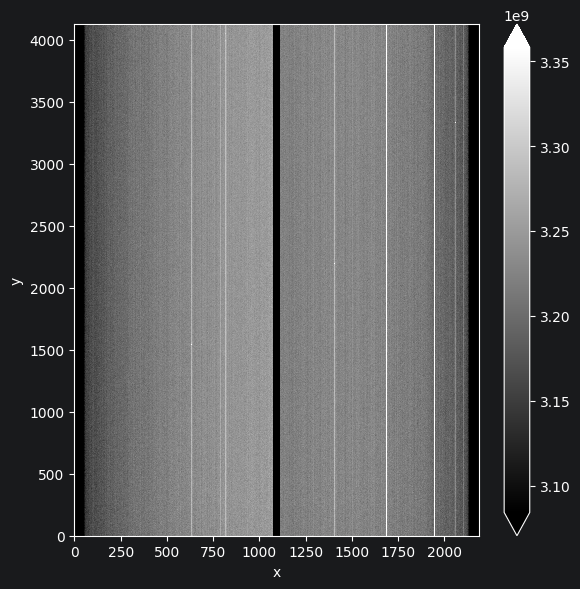

In [6]:
# Display the first DetImage from an input file
det_image = res.data[0]

# Show the DetImage using its built-in show method that takes kwargs for plt.imshow
# For example, to set the colormap to 'gray', and scale the values using vmin, vmax from ZScaleInterval:
from astropy.visualization import ZScaleInterval
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(det_image.data)
ax = det_image.show(cmap='gray', vmin=vmin, vmax=vmax)

Each `DetImage` contains an `outputs` dict keyed by amplifier id (strings from the detector config).
An `Output` object typically contains:
- `.data`: the amplifier sub-image.
- Detector-type specific attributes like `.serial_prescan`, `.serial_overscan`, `.parallel_prescan`, `.parallel_overscan`: slices you can set or read in `CCDOutput`

In [7]:
det_image.outputs.keys()

dict_keys(['E1', 'F1'])

In [8]:
det_image.outputs['E1'].parallel_overscan

slice(4105, 4125, 1)

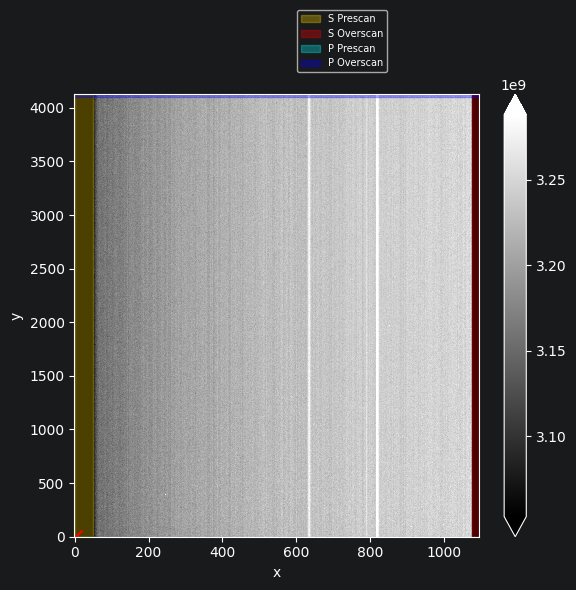

In [9]:
# Plotting the first Output
output = det_image.outputs['E1']
vmin, vmax = interval.get_limits(output.data)

ax = output.show(cmap='gray', vmin=vmin, vmax=vmax, shade_regions=True, origin='lower')

## Building a focal plane image

`FocalPlaneImage` combines multiple `DetImage` instances into a single array representing the focal plane.
- Provide: number of detectors, full dimension, and the list of `DetImage`s.
- The resulting object contains a consolidated `.data` array and a `.table` describing detector placement.

The DEIMOS raw FITS used above contains 8 extensions, corresponding to 8 detectors in the focal plane, each detector with two outputs.

The focal plane position information needs to be specified in the detector configuration file.

In [11]:
from eregion.datamodels import FocalPlaneImage
fpimage = FocalPlaneImage(num_detectors=8, dim=(4125*2*0.015, 2188*4*0.015), det_images=res.data)

Focal plane usage tips
- Ensure `num_detectors` and `dim` reflect your detector layout.
- Use `table` to verify that detector positions were applied correctly.

In [12]:
fpimage.table

,det_id,x_min,x_max,y_min,y_max,angle,flip_x,flip_y
0,det_1,-4376,-2188,0,4125,0.0,False,True
1,det_2,-2188,0,0,4125,0.0,False,True
2,det_3,0,2188,0,4125,0.0,False,True
3,det_4,2188,4376,0,4125,0.0,False,True
4,det_5,2188,4376,-4125,0,0.0,True,False
5,det_6,0,2188,-4125,0,0.0,True,False
6,det_7,-2188,0,-4125,0,0.0,True,False
7,det_8,-4376,-2188,-4125,0,0.0,True,False


<Axes: xlabel='x', ylabel='y'>

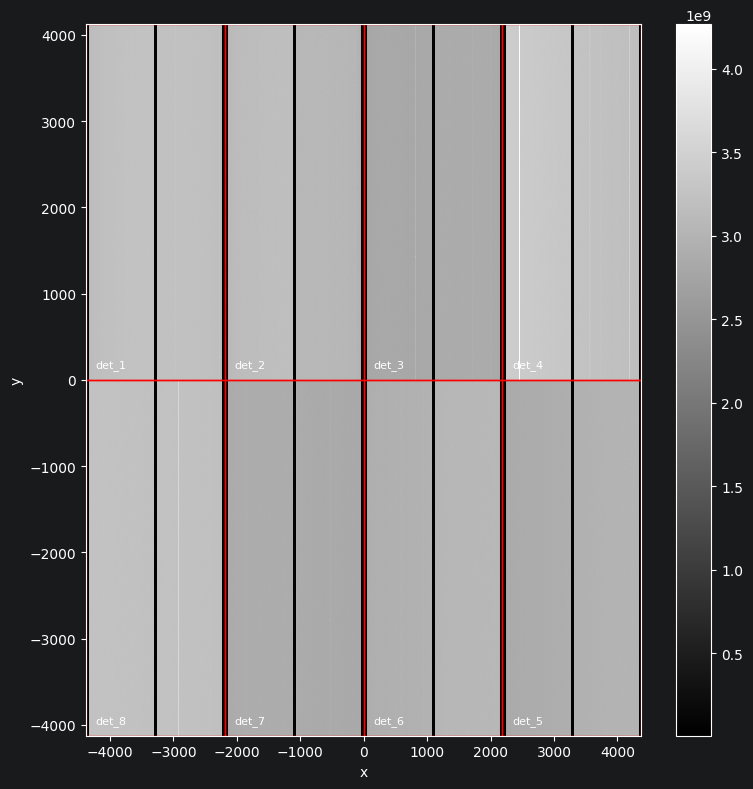

In [15]:
fpimage.show(cmap='gray', show_det_id=True)

## Example 2: Image loading with custom identifier function

In [1]:
from eregion.tasks.imagegen import ImageCreator
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci.yaml')

# load custom identifier function to identify bias frames based on filename, supply as identifier_func to ImageCreator.run
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
res = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/dark/SCI/20260527-155*/*_bias_*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS, fileloader_func=load_image_fits_DEIMOS)

2026-07-22 16:31:34,397 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-22 16:31:34,399 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/dark/SCI/20260527-155*/*_bias_*.fits is a glob pattern


Check the result ImageBundle to confirm bias images were identified and loaded correctly.

In [2]:
res.data.list

,type,det_id,filename,object
0,bias,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e23d940>
1,bias,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e19fc50>
2,bias,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e19f110>
3,bias,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e1ecfc0>
4,bias,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e1eed70>
5,bias,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e27da30>
6,bias,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e153f00>
7,bias,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e286580>
8,bias,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e197c50>
9,bias,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10e197a50>


<Axes: xlabel='x', ylabel='y'>

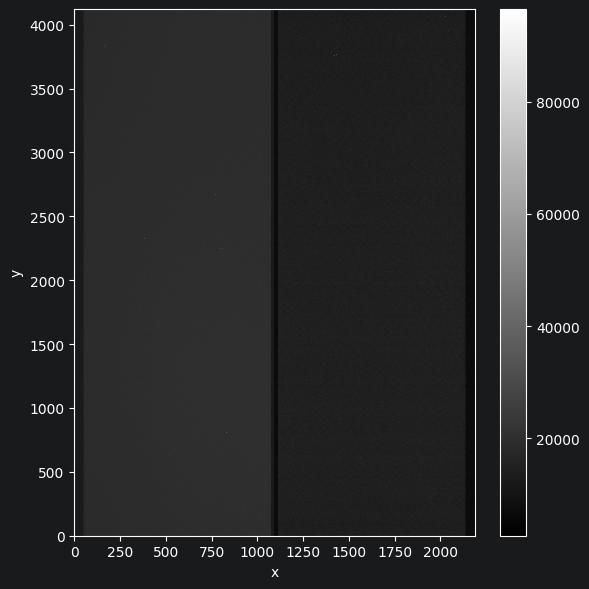

In [14]:
res.data[0].show(cmap='gray')

## Example 3: Create master bias using tasks directly in the notebook

Use the `MasterBias` task to combine many bias frames into a single master bias frame.
- Typical method: `'median'` or `'mean'`.
- Input: a list of `DetImage` objects or `ImageBundle` of bias type.
- Output: `CalibrationResult` object containing master bias frames in `master_bias` attribute.
- Inspect the result and visualize with the same `show()` helpers.

In [4]:
from eregion.tasks.calibration import MasterBias
# To get the list of available methods for any task, use Task.print_methods()
MasterBias().print_methods()

2026-07-22 16:31:56,662 - MasterBias - INFO - Available methods for MasterBias:
2026-07-22 16:31:56,662 - MasterBias - INFO - - median: <function median_combine at 0x10d3dc040>, (images: list[numpy.ndarray]) -> numpy.ndarray


In [8]:
# Create master bias task and run it
master_bias_task = MasterBias(method='median')
mb_res = master_bias_task.run(bias_images=res.data('type == "bias"'))

2026-07-22 16:32:17,804 - MasterBias - INFO - Setting method 'median' for task MasterBias.
2026-07-22 16:32:17,804 - MasterBias - INFO - Setting method 'median' for task MasterBias.
2026-07-22 16:32:17,804 - MasterBias - INFO - Setting method 'median' for task MasterBias.


In [10]:
mb_res.master_bias

,type,det_id,filename,object
0,master_bias,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec67380>
1,master_bias,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec67530>
2,master_bias,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec675c0>
3,master_bias,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec67650>
4,master_bias,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec676e0>
5,master_bias,det_6,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec67770>
6,master_bias,det_7,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec67800>
7,master_bias,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10ec67890>


<Axes: xlabel='x', ylabel='y'>

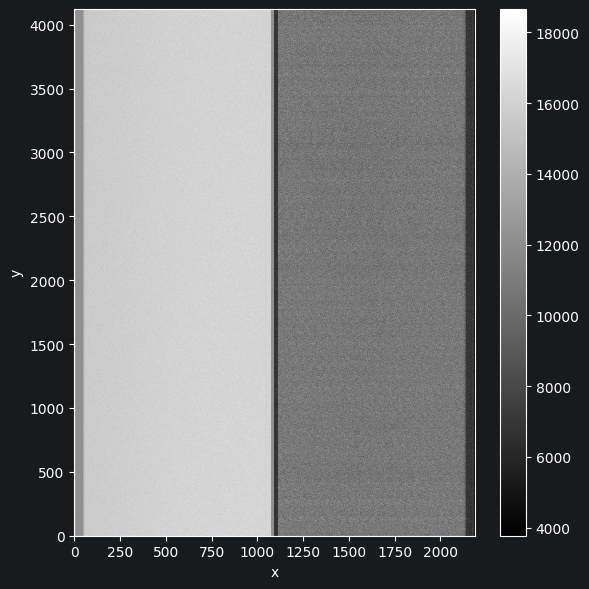

In [11]:
mb_res.master_bias[0].show(cmap='gray')